<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/CO2_Dehydration_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CO₂ dehydration for pipeline transport with NeqSim

**Audience.** Process, flow-assurance, and CCS engineers who know basic phase equilibrium and
want a reproducible screening workflow.

**Prerequisites.** Familiarity with pressure, temperature, mole fraction, mass flow, and a
steady-state process flowsheet. All calculations use SI engineering units: °C, bara, kg/h,
kg/m³, and mole-based ppmv.

## Learning objectives

After completing the notebook you can:

1. calculate saturated water content in CO₂-rich fluid with SRK-CPA;
2. map impurity-fluid phase behavior and density over a transport window;
3. assemble `Stream`, `SimpleTEGAbsorber`, and `ProcessSystem` objects;
4. audit total and component mass balances around a TEG contactor;
5. screen solvent rate, purity, and hydraulic loading against an illustrative water target; and
6. identify where equilibrium-stage screening must give way to rate-based and corrosion design.

In [1]:
import importlib.util
import platform
import subprocess
import sys
from importlib.metadata import version

if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import jpype
from IPython.display import display

from neqsim import jneqsim
from neqsim.thermo import TPflash, fluid, phaseenvelope

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.fontsize": 9,
    }
)

NEQSIM_VERSION = version("neqsim")
PYTHON_VERSION = platform.python_version()
JAVA_VERSION = str(jpype.JClass("java.lang.System").getProperty("java.version"))

runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "Python", "Java"],
        "Version": [NEQSIM_VERSION, PYTHON_VERSION, JAVA_VERSION],
    }
)
display(runtime_table)

,Runtime,Version
0,NeqSim,3.16.0
1,Python,3.12.13
2,Java,17.0.19


## Engineering question and scope

Captured CO₂ must remain inside a specified phase and water-content envelope through
conditioning, transport, and injection. Water can form a separate aqueous phase, hydrates, or
corrosive carbonic-acid-containing liquid. This notebook asks:

> Can an equilibrium-stage TEG contactor screen a wet CO₂-rich stream to an illustrative
> 50 ppmv water target while preserving mass and staying within a simple hydraulic limit?

The 50 ppmv value is a **teaching target**, not a universal code limit. A project specification
depends on composition, pressure-temperature history, materials, impurities, and governing
standards. All pressures here are absolute.

In [2]:
CO2_FEED_KG_PER_HOUR = 500_000.0
BASE_TEG_KG_PER_HOUR = 5_000.0
CONTACTOR_TEMPERATURE_C = 30.0
CONTACTOR_PRESSURE_BARA = 110.0
WATER_TARGET_PPMV = 50.0
BASE_TEG_MASS_FRACTION = 0.99
CONTACTOR_STAGES = 5
STAGE_EFFICIENCY = 0.50
CONTACTOR_DIAMETER_M = 3.0

assumption_table = pd.DataFrame(
    [
        ("CO₂-rich feed mass rate", CO2_FEED_KG_PER_HOUR, "kg/h"),
        ("Base lean-TEG rate", BASE_TEG_KG_PER_HOUR, "kg/h"),
        ("Contactor temperature", CONTACTOR_TEMPERATURE_C, "°C"),
        ("Contactor pressure", CONTACTOR_PRESSURE_BARA, "bara"),
        ("Illustrative water target", WATER_TARGET_PPMV, "ppmv"),
        ("Lean-TEG mass fraction", BASE_TEG_MASS_FRACTION, "kg/kg"),
        ("Actual stages", CONTACTOR_STAGES, "-"),
        ("Stage efficiency", STAGE_EFFICIENCY, "-"),
        ("Screening diameter", CONTACTOR_DIAMETER_M, "m"),
    ],
    columns=["Input", "Value", "Unit"],
)
display(assumption_table)

,Input,Value,Unit
0,CO₂-rich feed mass rate,500000.00,kg/h
1,Base lean-TEG rate,5000.00,kg/h
2,Contactor temperature,30.00,°C
3,Contactor pressure,110.00,bara
4,Illustrative water target,50.00,ppmv
5,Lean-TEG mass fraction,0.99,kg/kg
6,Actual stages,5.00,-
7,Stage efficiency,0.50,-
8,Screening diameter,3.00,m


## Thermodynamic representation

NeqSim stores composition, temperature, pressure, phases, and properties in a thermodynamic
`SystemInterface`. SRK-CPA combines an SRK cubic term with association sites, which is useful for
water and glycol hydrogen bonding. At equilibrium, each component has equal fugacity in every
coexisting phase:

$$

f_i^\alpha = f_i^\beta

$$

For the water component, NeqSim solves this condition together with material balances and the
EOS. Mole-based water content is reported as:

$$

w_{\mathrm{ppmv}} = 10^6 x_{\mathrm{water}}

$$

CPA is a screening model here. Binary parameters and impurity chemistry must be validated for a
specific captured-CO₂ source.

In [3]:
def add_components(thermo_system, composition):
    for component_name, amount in composition.items():
        thermo_system.addComponent(component_name, float(amount))


def build_saturated_co2(temperature_c, pressure_bara, composition=None):
    gas_composition = composition or {"CO2": 99.0, "nitrogen": 1.0}
    saturated_system = fluid("cpa-statoil")
    add_components(saturated_system, gas_composition)
    saturated_system.addComponent("water", 5.0)
    saturated_system.addComponent("TEG", 1.0e-12)
    saturated_system.setTemperature(float(temperature_c), "C")
    saturated_system.setPressure(float(pressure_bara), "bara")
    saturated_system.setMixingRule(10)
    saturated_system.setMultiPhaseCheck(True)
    TPflash(saturated_system)
    saturated_system.initProperties()
    return saturated_system


def water_ppmv(thermo_system, phase_index=0):
    water_fraction = float(
        thermo_system.getPhase(phase_index).getComponent("water").getx()
    )
    return water_fraction * 1.0e6


def component_mass_rate(stream_object, component_name):
    thermo_system = stream_object.getFluid()
    mass_rate = 0.0
    for phase_index in range(int(thermo_system.getNumberOfPhases())):
        component = thermo_system.getPhase(phase_index).getComponent(component_name)
        molar_rate = float(component.getNumberOfMolesInPhase())
        molar_mass = float(component.getMolarMass())
        mass_rate += molar_rate * molar_mass * 3_600.0
    return mass_rate

## Preservation inventory from the original draft

The original notebook contained five substantive, unexecuted examples. Every intention is retained:

1. saturated water content versus temperature and pressure;
2. a phase envelope for CO₂ with N₂, CH₄, H₂O, H₂S, and O₂;
3. transport-density curves versus temperature and pressure;
4. a 500 t/h CO₂, 5 t/h, 99 wt% TEG contactor base case; and
5. TEG-rate sensitivity beginning at 0.5 t/h.

No technical figure output existed to preserve. The revised notebook executes and retains each
recomputed figure, adds conservation checks, and extends the rate range far enough to reveal
whether the illustrative target is actually reached.

In [4]:
saturated_base = build_saturated_co2(
    CONTACTOR_TEMPERATURE_C,
    CONTACTOR_PRESSURE_BARA,
    {"CO2": 98.5, "nitrogen": 1.0},
)

phase_rows = []
for phase_index in range(int(saturated_base.getNumberOfPhases())):
    phase = saturated_base.getPhase(phase_index)
    phase_rows.append(
        {
            "Phase": str(phase.getType()),
            "Phase fraction [-]": float(phase.getBeta()),
            "Water [mole fraction]": float(phase.getComponent("water").getx()),
            "CO₂ [mole fraction]": float(phase.getComponent("CO2").getx()),
            "Density [kg/m³]": float(phase.getDensity("kg/m3")),
        }
    )

phase_table = pd.DataFrame(phase_rows)
display(phase_table)

base_saturated_water_ppmv = water_ppmv(saturated_base)
print(f"Saturated CO₂-rich phase water content: {base_saturated_water_ppmv:,.3f} ppmv")

Saturated CO₂-rich phase water content: 3,309.780 ppmv


,Phase,Phase fraction [-],Water [mole fraction],CO₂ [mole fraction],Density [kg/m³]
0,GAS,0.954206,0.003310,0.986664,663.404475
1,AQUEOUS,0.045794,0.975853,0.024102,1003.117302


The excess-water flash creates a CO₂-rich phase and an aqueous phase. Only the CO₂-rich phase is
sent to the contactor. This is preferable to guessing an inlet water fraction: it establishes a
thermodynamically saturated boundary condition at the selected temperature and pressure.

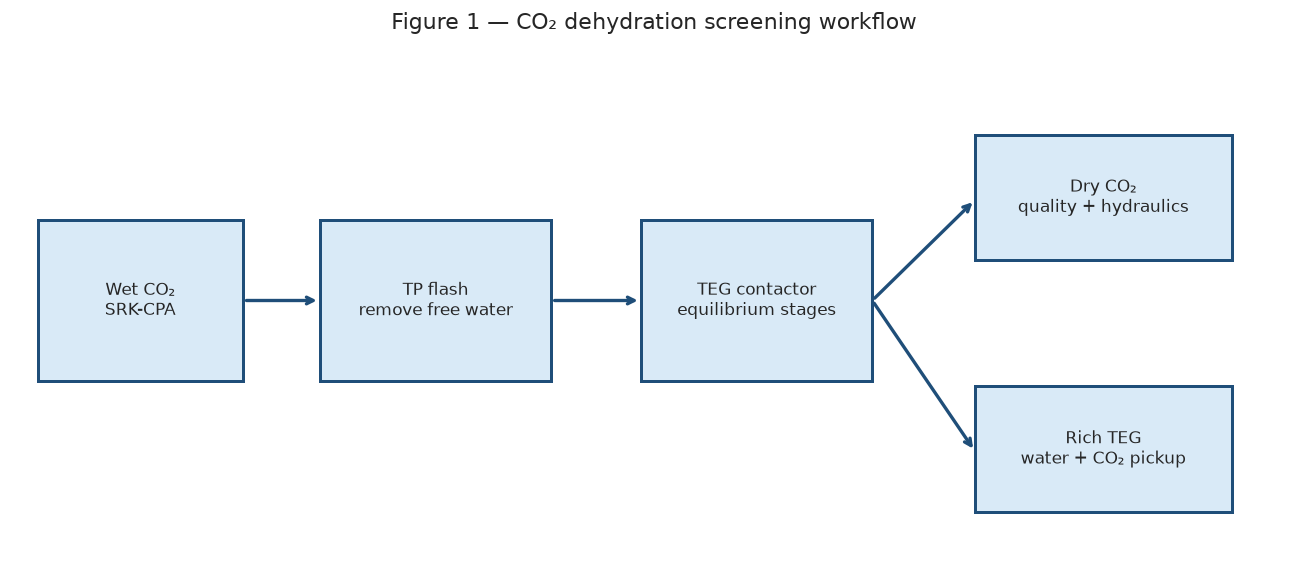

In [5]:
fig, axis = plt.subplots(figsize=(11, 4.8))
axis.axis("off")

boxes = [
    (0.02, 0.34, 0.16, 0.32, "Wet CO₂\nSRK-CPA"),
    (0.24, 0.34, 0.18, 0.32, "TP flash\nremove free water"),
    (0.49, 0.34, 0.18, 0.32, "TEG contactor\nequilibrium stages"),
    (0.75, 0.58, 0.20, 0.25, "Dry CO₂\nquality + hydraulics"),
    (0.75, 0.08, 0.20, 0.25, "Rich TEG\nwater + CO₂ pickup"),
]

for left, bottom, width, height, label in boxes:
    patch = plt.Rectangle(
        (left, bottom),
        width,
        height,
        facecolor="#D9EAF7",
        edgecolor="#1F4E79",
        linewidth=1.8,
    )
    axis.add_patch(patch)
    axis.text(
        left + width / 2.0,
        bottom + height / 2.0,
        label,
        ha="center",
        va="center",
        fontsize=10,
    )

arrow_pairs = [
    ((0.18, 0.50), (0.24, 0.50)),
    ((0.42, 0.50), (0.49, 0.50)),
    ((0.67, 0.50), (0.75, 0.70)),
    ((0.67, 0.50), (0.75, 0.20)),
]
for start, end in arrow_pairs:
    axis.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops={"arrowstyle": "->", "color": "#1F4E79", "lw": 2.0},
    )

axis.set_xlim(0.0, 1.0)
axis.set_ylim(0.0, 1.0)
axis.set_title("Figure 1 — CO₂ dehydration screening workflow", pad=12)
plt.tight_layout()
plt.show()

## 1. Saturated water content map

The map uses fresh SRK-CPA systems for every state, preventing hidden state from one flash from
contaminating the next. Temperature generally increases the water-carrying capacity. Near a phase
boundary, pressure trends may change because dense-fluid behavior is strongly non-ideal.

In [6]:
water_map_pressures_bara = np.array([20.0, 40.0, 60.0, 80.0, 100.0, 150.0, 200.0])
water_map_temperatures_c = np.arange(0.0, 65.0, 5.0)
water_map_rows = []

for pressure_bara in water_map_pressures_bara:
    for temperature_c in water_map_temperatures_c:
        saturated_system = build_saturated_co2(
            temperature_c,
            pressure_bara,
        )
        water_map_rows.append(
            {
                "Pressure [bara]": pressure_bara,
                "Temperature [°C]": temperature_c,
                "Water [ppmv]": water_ppmv(saturated_system),
                "CO₂-rich density [kg/m³]": float(
                    saturated_system.getPhase(0).getDensity("kg/m3")
                ),
            }
        )

water_map = pd.DataFrame(water_map_rows)
display(water_map.head(10))

,Pressure [bara],Temperature [°C],Water [ppmv],CO₂-rich density [kg/m³]
0,20.0,0.0,416.721189,45.093484
1,20.0,5.0,578.887842,43.804506
2,20.0,10.0,795.207700,42.607700
3,20.0,15.0,1080.689642,41.491233
4,20.0,20.0,1453.605438,40.445244
5,20.0,25.0,1935.984437,39.461393
6,20.0,30.0,2554.142903,38.532527
7,20.0,35.0,3339.244613,37.652424
8,20.0,40.0,4327.888572,36.815604
9,20.0,45.0,5562.718985,36.017176


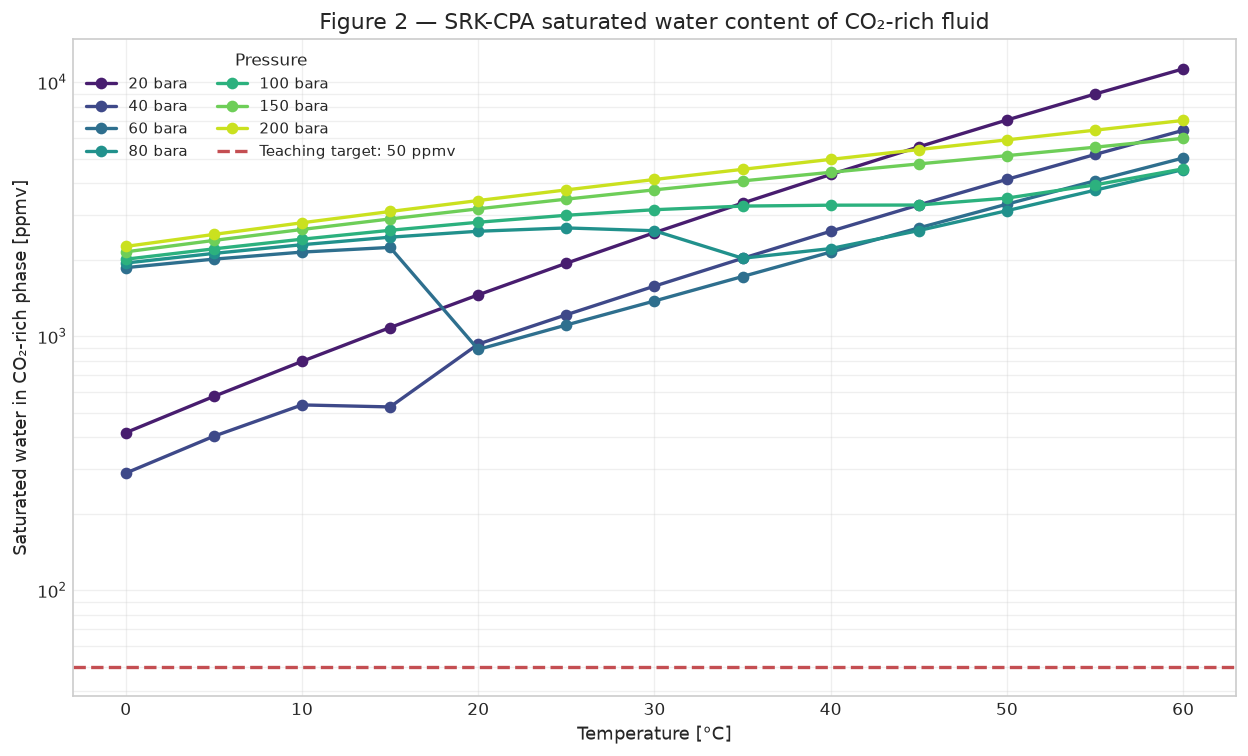

In [7]:
fig, axis = plt.subplots(figsize=(10.5, 6.4))
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(water_map_pressures_bara)))

for pressure_bara, color in zip(water_map_pressures_bara, colors):
    pressure_data = water_map.loc[
        water_map["Pressure [bara]"] == pressure_bara
    ]
    axis.semilogy(
        pressure_data["Temperature [°C]"],
        pressure_data["Water [ppmv]"],
        marker="o",
        linewidth=2.0,
        color=color,
        label=f"{pressure_bara:.0f} bara",
    )

axis.axhline(
    WATER_TARGET_PPMV,
    color="#C44E52",
    linestyle="--",
    linewidth=2.0,
    label=f"Teaching target: {WATER_TARGET_PPMV:.0f} ppmv",
)
axis.set_xlabel("Temperature [°C]")
axis.set_ylabel("Saturated water in CO₂-rich phase [ppmv]")
axis.set_title("Figure 2 — SRK-CPA saturated water content of CO₂-rich fluid")
axis.legend(title="Pressure", ncol=2)
axis.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

All saturation points are far wetter than the teaching target, so dehydration is required before
the fluid follows a cooling or pressure-reduction path. The curves are equilibrium predictions,
not a substitute for a project-qualified water-solubility correlation or experimental data.

## 2. Impurity-fluid phase envelope

The original relative composition is retained and normalized explicitly. The envelope solves
vapor-liquid coexistence for an SRK mixture. It is useful for identifying an operating window,
but it does not include hydrate, solid, corrosion, or nonequilibrium effects.

In [8]:
raw_envelope_composition = {
    "CO2": 96.0,
    "nitrogen": 2.0,
    "methane": 1.0,
    "water": 0.005,
    "H2S": 0.01,
    "oxygen": 0.5,
}
composition_total = sum(raw_envelope_composition.values())
envelope_composition = {
    name: amount / composition_total
    for name, amount in raw_envelope_composition.items()
}

envelope_fluid = fluid("srk")
add_components(envelope_fluid, envelope_composition)
envelope_fluid.setTemperature(25.0, "C")
envelope_fluid.setPressure(80.0, "bara")
envelope_fluid.setMixingRule("classic")

envelope_operation = phaseenvelope(envelope_fluid)
dew_temperature_k = np.asarray(
    list(envelope_operation.getOperation().get("dewT")),
    dtype=float,
)
dew_pressure_bar = np.asarray(
    list(envelope_operation.getOperation().get("dewP")),
    dtype=float,
)
bubble_temperature_k = np.asarray(
    list(envelope_operation.getOperation().get("bubT")),
    dtype=float,
)
bubble_pressure_bar = np.asarray(
    list(envelope_operation.getOperation().get("bubP")),
    dtype=float,
)

dew_mask = np.isfinite(dew_temperature_k) & np.isfinite(dew_pressure_bar)
bubble_mask = np.isfinite(bubble_temperature_k) & np.isfinite(bubble_pressure_bar)

print(f"Normalized composition sum: {sum(envelope_composition.values()):.12f}")
print(f"Finite dew points: {int(dew_mask.sum())}")
print(f"Finite bubble points: {int(bubble_mask.sum())}")

Normalized composition sum: 1.000000000000
Finite dew points: 32
Finite bubble points: 51


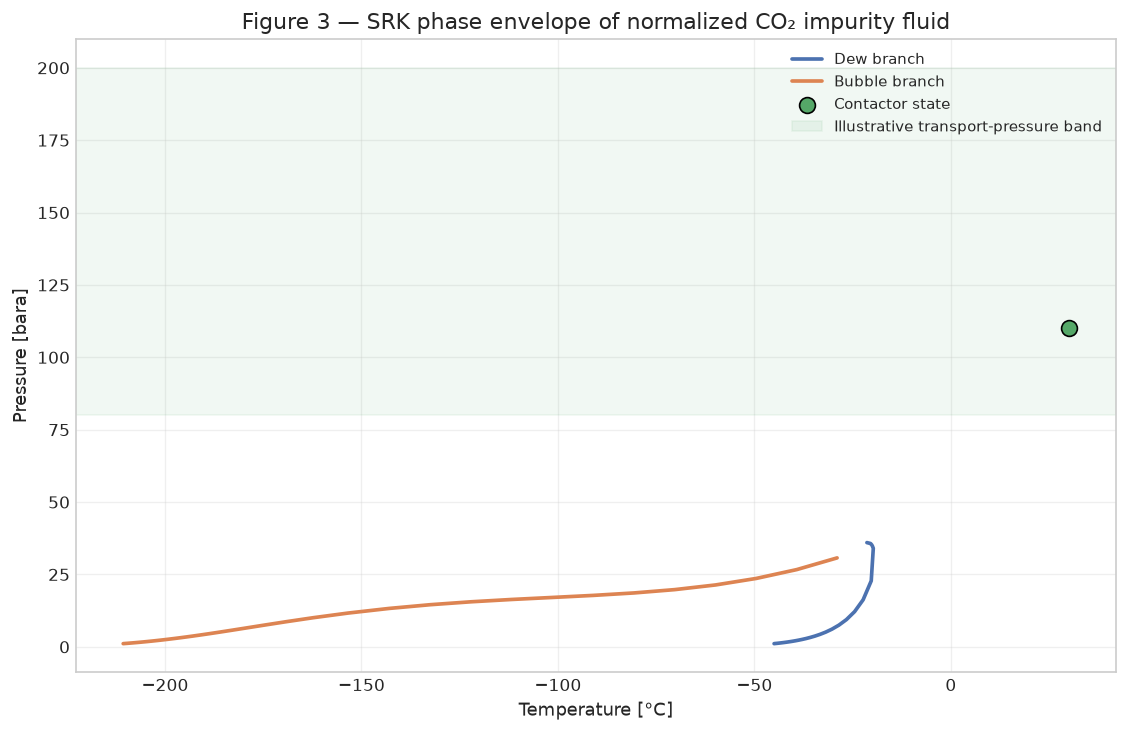

In [9]:
fig, axis = plt.subplots(figsize=(9.5, 6.2))
axis.plot(
    dew_temperature_k[dew_mask] - 273.15,
    dew_pressure_bar[dew_mask],
    color="#4C72B0",
    linewidth=2.2,
    label="Dew branch",
)
axis.plot(
    bubble_temperature_k[bubble_mask] - 273.15,
    bubble_pressure_bar[bubble_mask],
    color="#DD8452",
    linewidth=2.2,
    label="Bubble branch",
)
axis.scatter(
    [CONTACTOR_TEMPERATURE_C],
    [CONTACTOR_PRESSURE_BARA],
    color="#55A868",
    edgecolor="black",
    s=90,
    zorder=4,
    label="Contactor state",
)
axis.axhspan(
    80.0,
    200.0,
    color="#55A868",
    alpha=0.08,
    label="Illustrative transport-pressure band",
)
axis.set_xlabel("Temperature [°C]")
axis.set_ylabel("Pressure [bara]")
axis.set_title("Figure 3 — SRK phase envelope of normalized CO₂ impurity fluid")
axis.legend()
axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The contactor state lies above the computed low-temperature vapor-liquid envelope for this
specific normalized assay. A phase-envelope plot alone does not prove single-phase transport:
the complete route, water dropout, hydrate stability, and transient pressure-temperature paths
must also be checked.

## 3. Transport density and a reference-model check

Density controls actual volumetric flow and strongly affects equipment velocity. The original
SRK impurity-fluid curves are preserved. Pure-CO₂ Span-Wagner density at 110 bara is added as a
reference-model comparison; it is not a benchmark for the impurity fluid.

In [10]:
density_temperatures_c = np.arange(5.0, 50.0, 2.0)
density_pressures_bara = np.array([80.0, 100.0, 120.0, 150.0, 200.0])
density_rows = []

for pressure_bara in density_pressures_bara:
    for temperature_c in density_temperatures_c:
        transport_fluid = fluid("srk")
        add_components(
            transport_fluid,
            {
                "CO2": 96.0,
                "nitrogen": 2.0,
                "methane": 1.0,
                "oxygen": 1.0,
            },
        )
        transport_fluid.setTemperature(temperature_c, "C")
        transport_fluid.setPressure(pressure_bara, "bara")
        transport_fluid.setMixingRule("classic")
        TPflash(transport_fluid)
        transport_fluid.initProperties()
        density_rows.append(
            {
                "Pressure [bara]": pressure_bara,
                "Temperature [°C]": temperature_c,
                "SRK mixture density [kg/m³]": float(
                    transport_fluid.getDensity("kg/m3")
                ),
            }
        )

density_table = pd.DataFrame(density_rows)

span_wagner_density = []
for temperature_c in density_temperatures_c:
    reference_fluid = fluid("span-wagner")
    reference_fluid.addComponent("CO2", 1.0)
    reference_fluid.setTemperature(temperature_c, "C")
    reference_fluid.setPressure(CONTACTOR_PRESSURE_BARA, "bara")
    TPflash(reference_fluid)
    reference_fluid.initProperties()
    span_wagner_density.append(float(reference_fluid.getDensity("kg/m3")))

display(density_table.head())

,Pressure [bara],Temperature [°C],SRK mixture density [kg/m³]
0,80.0,5.0,824.964395
1,80.0,7.0,807.489671
2,80.0,9.0,789.129448
3,80.0,11.0,769.742849
4,80.0,13.0,749.146566


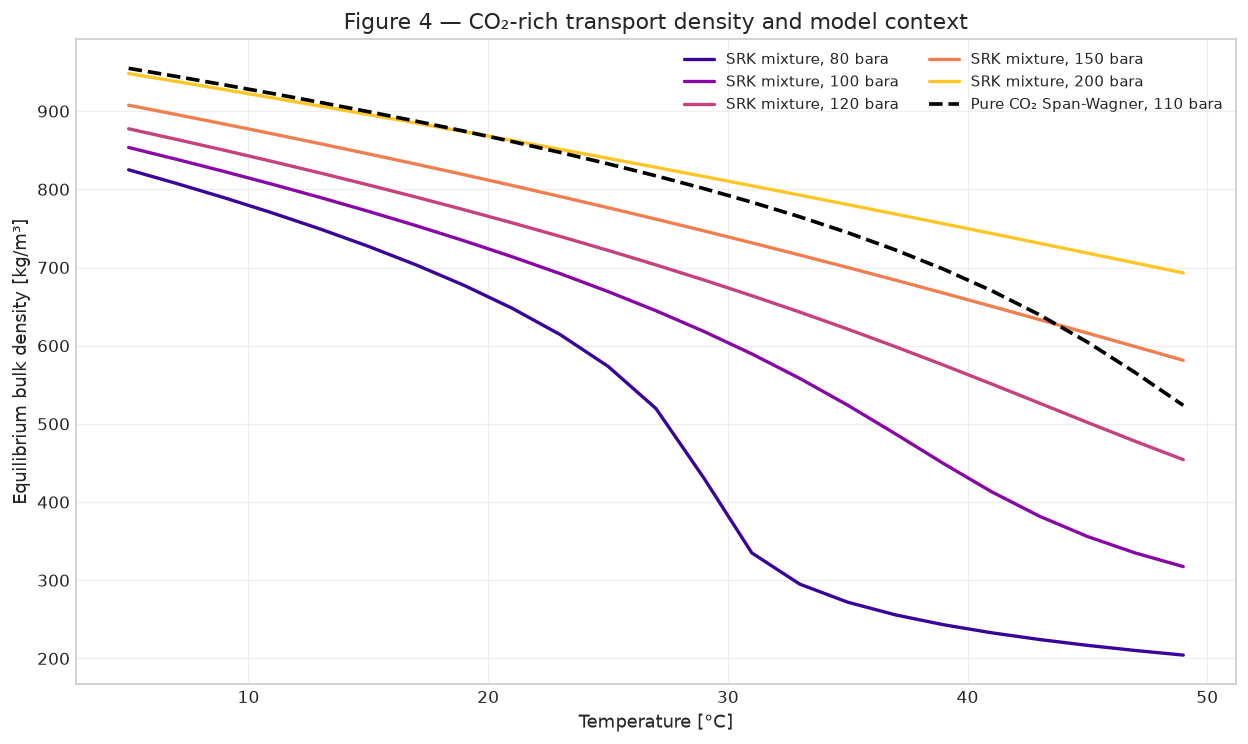

In [11]:
fig, axis = plt.subplots(figsize=(10.5, 6.3))
colors = plt.cm.plasma(np.linspace(0.08, 0.88, len(density_pressures_bara)))

for pressure_bara, color in zip(density_pressures_bara, colors):
    pressure_data = density_table.loc[
        density_table["Pressure [bara]"] == pressure_bara
    ]
    axis.plot(
        pressure_data["Temperature [°C]"],
        pressure_data["SRK mixture density [kg/m³]"],
        linewidth=2.0,
        color=color,
        label=f"SRK mixture, {pressure_bara:.0f} bara",
    )

axis.plot(
    density_temperatures_c,
    span_wagner_density,
    color="#000000",
    linestyle="--",
    linewidth=2.2,
    label=f"Pure CO₂ Span-Wagner, {CONTACTOR_PRESSURE_BARA:.0f} bara",
)
axis.set_xlabel("Temperature [°C]")
axis.set_ylabel("Equilibrium bulk density [kg/m³]")
axis.set_title("Figure 4 — CO₂-rich transport density and model context")
axis.legend(ncol=2)
axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The sharpest density changes occur close to the critical region. At the 110 bara contactor
pressure, comparing an impurity SRK prediction with a pure-fluid Span-Wagner curve separates
composition effects from reference-EOS effects. Detailed pipeline hydraulics should use a
qualified composition and model.

## 4. Native NeqSim TEG contactor

`SimpleTEGAbsorber` is an equilibrium-stage screening model. NeqSim estimates an absorption
factor, the theoretical-stage equivalent, dry-product composition, rich solvent, and Fs-factor
capacity. Its simplified stage efficiency gives $N_{\mathrm{theoretical}} = \eta N$.

The reported water removal is:

$$

\eta_w = 1 - \frac{\dot m_{w,\mathrm{dry}}}{\dot m_{w,\mathrm{feed}}}

$$

The hydraulic screening factor is:

$$

F_s = v_s \sqrt{\rho_{\mathrm{CO_2}}}

$$

The direct Java gateway is used because `SimpleTEGAbsorber` is a specialized class outside the
small Python wrapper set. A negligible TEG trace is included in the gas template only to align
component lists before the absorber mixes streams; its mass contribution is below numerical
reporting precision.

In [12]:
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
Stream = jneqsim.process.equipment.stream.Stream
ProcessSystem = jneqsim.process.processmodel.ProcessSystem
SimpleTEGAbsorber = jneqsim.process.equipment.absorber.SimpleTEGAbsorber


def build_teg_process(
    teg_rate_kg_per_hour,
    teg_mass_fraction=0.99,
    gas_rate_kg_per_hour=CO2_FEED_KG_PER_HOUR,
    number_of_stages=CONTACTOR_STAGES,
    stage_efficiency=STAGE_EFFICIENCY,
    diameter_m=CONTACTOR_DIAMETER_M,
):
    saturated_system = build_saturated_co2(
        CONTACTOR_TEMPERATURE_C,
        CONTACTOR_PRESSURE_BARA,
        {"CO2": 98.5, "nitrogen": 1.0},
    )
    wet_co2_fluid = saturated_system.phaseToSystem("gas")

    wet_co2_stream = Stream("Wet CO2 feed", wet_co2_fluid)
    wet_co2_stream.setFlowRate(float(gas_rate_kg_per_hour), "kg/hr")
    wet_co2_stream.setTemperature(CONTACTOR_TEMPERATURE_C, "C")
    wet_co2_stream.setPressure(CONTACTOR_PRESSURE_BARA, "bara")

    lean_teg_fluid = SystemSrkCPAstatoil(
        273.15 + CONTACTOR_TEMPERATURE_C,
        CONTACTOR_PRESSURE_BARA,
    )
    lean_teg_fluid.addComponent("CO2", 1.0e-12)
    lean_teg_fluid.addComponent("nitrogen", 1.0e-12)
    lean_teg_fluid.addComponent(
        "water",
        100.0 * (1.0 - float(teg_mass_fraction)),
    )
    lean_teg_fluid.addComponent(
        "TEG",
        100.0 * float(teg_mass_fraction),
    )
    lean_teg_fluid.setMixingRule(10)
    lean_teg_fluid.setMultiPhaseCheck(True)

    lean_teg_stream = Stream("Lean TEG", lean_teg_fluid)
    lean_teg_stream.setFlowRate(float(teg_rate_kg_per_hour), "kg/hr")
    lean_teg_stream.setTemperature(CONTACTOR_TEMPERATURE_C, "C")
    lean_teg_stream.setPressure(CONTACTOR_PRESSURE_BARA, "bara")

    absorber = SimpleTEGAbsorber("CO2 TEG contactor")
    absorber.addGasInStream(wet_co2_stream)
    absorber.addSolventInStream(lean_teg_stream)
    absorber.setNumberOfStages(int(number_of_stages))
    absorber.setStageEfficiency(float(stage_efficiency))
    absorber.setInternalDiameter(float(diameter_m))

    process = ProcessSystem()
    process.add(wet_co2_stream)
    process.add(lean_teg_stream)
    process.add(absorber)
    process.run()

    return {
        "process": process,
        "feed": wet_co2_stream,
        "lean_teg": lean_teg_stream,
        "absorber": absorber,
        "dry_co2": absorber.getGasOutStream(),
        "rich_teg": absorber.getLiquidOutStream(),
    }


def summarize_teg_case(case):
    feed = case["feed"]
    lean_teg = case["lean_teg"]
    dry_co2 = case["dry_co2"]
    rich_teg = case["rich_teg"]
    absorber = case["absorber"]

    inlet_water = component_mass_rate(feed, "water")
    dry_water = component_mass_rate(dry_co2, "water")
    inlet_mass = feed.getFlowRate("kg/hr") + lean_teg.getFlowRate("kg/hr")
    outlet_mass = dry_co2.getFlowRate("kg/hr") + rich_teg.getFlowRate("kg/hr")

    return {
        "Wet CO₂ water [ppmv]": water_ppmv(feed.getFluid()),
        "Dry CO₂ water [ppmv]": water_ppmv(dry_co2.getFluid()),
        "Water removal [-]": 1.0 - dry_water / inlet_water,
        "Dry CO₂ [kg/h]": dry_co2.getFlowRate("kg/hr"),
        "Rich TEG [kg/h]": rich_teg.getFlowRate("kg/hr"),
        "Mass residual [kg/h]": inlet_mass - outlet_mass,
        "Fs factor [Pa^0.5]": absorber.getFsFactor(),
        "Fs utilization [%]": 100.0 * absorber.getFsFactorUtilization(),
        "Minimum diameter [m]": absorber.getMinimumDiameterForFsLimit(),
    }

In [13]:
base_case = build_teg_process(
    BASE_TEG_KG_PER_HOUR,
    BASE_TEG_MASS_FRACTION,
)
base_results = summarize_teg_case(base_case)

base_result_table = pd.DataFrame(
    {
        "Quantity": list(base_results.keys()),
        "Value": list(base_results.values()),
    }
)
display(base_result_table)

print(base_case["absorber"].validateContactorDesign())

TEG Contactor Design Validation
Fs factor: 0.764 m/s*sqrt(kg/m3) (max: 3.0)
Fs utilization: 25.5%
Fs within limit: OK
Gas load factor (Ks): 0.0476 m/s
NTU: 1.68
Number of theoretical stages: 2.50



,Quantity,Value
0,Wet CO₂ water [ppmv],3.309780e+03
1,Dry CO₂ water [ppmv],4.279474e+02
2,Water removal [-],8.712312e-01
3,Dry CO₂ [kg/h],4.992330e+05
4,Rich TEG [kg/h],5.766977e+03
5,Mass residual [kg/h],-5.820766e-11
6,Fs factor [Pa^0.5],7.635546e-01
7,Fs utilization [%],2.545182e+01
8,Minimum diameter [m],1.513494e+00


The preserved 5 t/h, 99 wt% TEG case does **not** meet the 50 ppmv target. The prior notebook
asserted success without executing the calculation; retaining the case while showing its failure
is the physically honest repair. The next study determines the solvent rate required by this
simplified model.

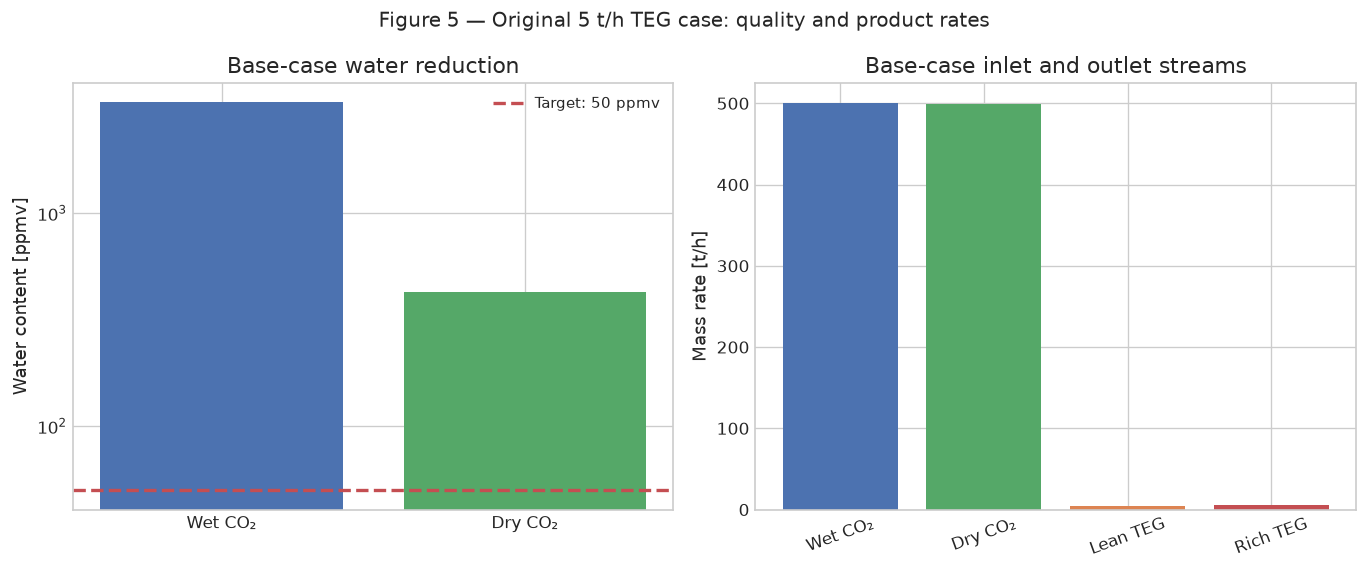

In [14]:
base_water_values = [
    base_results["Wet CO₂ water [ppmv]"],
    base_results["Dry CO₂ water [ppmv]"],
]
base_stream_rates = [
    base_case["feed"].getFlowRate("kg/hr") / 1_000.0,
    base_case["dry_co2"].getFlowRate("kg/hr") / 1_000.0,
    base_case["lean_teg"].getFlowRate("kg/hr") / 1_000.0,
    base_case["rich_teg"].getFlowRate("kg/hr") / 1_000.0,
]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
axes[0].bar(
    ["Wet CO₂", "Dry CO₂"],
    base_water_values,
    color=["#4C72B0", "#55A868"],
)
axes[0].axhline(
    WATER_TARGET_PPMV,
    color="#C44E52",
    linestyle="--",
    linewidth=2.0,
    label=f"Target: {WATER_TARGET_PPMV:.0f} ppmv",
)
axes[0].set_yscale("log")
axes[0].set_ylabel("Water content [ppmv]")
axes[0].set_title("Base-case water reduction")
axes[0].legend()

axes[1].bar(
    ["Wet CO₂", "Dry CO₂", "Lean TEG", "Rich TEG"],
    base_stream_rates,
    color=["#4C72B0", "#55A868", "#DD8452", "#C44E52"],
)
axes[1].set_ylabel("Mass rate [t/h]")
axes[1].set_title("Base-case inlet and outlet streams")
axes[1].tick_params(axis="x", rotation=20)

fig.suptitle("Figure 5 — Original 5 t/h TEG case: quality and product rates")
plt.tight_layout()
plt.show()

## 5. TEG circulation sensitivity

The original 0.5–14.5 t/h range is preserved at 0.5 t/h increments. Additional higher rates are
included because the preserved range never reaches the target. Every point creates and runs a
fresh `ProcessSystem`, so there is no state carry-over.

In [15]:
original_teg_rates = np.arange(500.0, 15_000.0, 500.0)
extended_teg_rates = np.array([17_500.0, 20_000.0, 22_500.0, 25_000.0, 30_000.0])
teg_rates_kg_per_hour = np.concatenate(
    [original_teg_rates, extended_teg_rates]
)

sensitivity_rows = []
for teg_rate_kg_per_hour in teg_rates_kg_per_hour:
    case = build_teg_process(
        teg_rate_kg_per_hour,
        BASE_TEG_MASS_FRACTION,
    )
    results = summarize_teg_case(case)
    sensitivity_rows.append(
        {
            "TEG rate [kg/h]": teg_rate_kg_per_hour,
            "Dry CO₂ water [ppmv]": results["Dry CO₂ water [ppmv]"],
            "Water removal [%]": 100.0 * results["Water removal [-]"],
            "Mass residual [kg/h]": results["Mass residual [kg/h]"],
        }
    )

teg_sensitivity = pd.DataFrame(sensitivity_rows)
passing_cases = teg_sensitivity.loc[
    teg_sensitivity["Dry CO₂ water [ppmv]"] <= WATER_TARGET_PPMV
]
selected_teg_rate = float(passing_cases.iloc[0]["TEG rate [kg/h]"])

display(teg_sensitivity)
print(f"Smallest tested passing TEG rate: {selected_teg_rate:,.0f} kg/h")

Smallest tested passing TEG rate: 22,500 kg/h


,TEG rate [kg/h],Dry CO₂ water [ppmv],Water removal [%],Mass residual [kg/h]
0,500.0,2288.089235,30.938880,5.820766e-11
1,1000.0,1823.002005,45.006947,-9.313226e-10
2,1500.0,1475.637977,55.506186,-1.164153e-10
3,2000.0,1204.520620,63.695490,5.820766e-11
4,2500.0,991.305148,70.132306,1.164153e-10
5,3000.0,822.959029,75.212240,-7.549534e-08
6,3500.0,689.410983,79.240593,-1.047738e-08
7,4000.0,582.843531,82.454073,-1.629815e-09
8,4500.0,497.229731,85.035005,-2.910383e-10
9,5000.0,427.947390,87.123116,-5.820766e-11


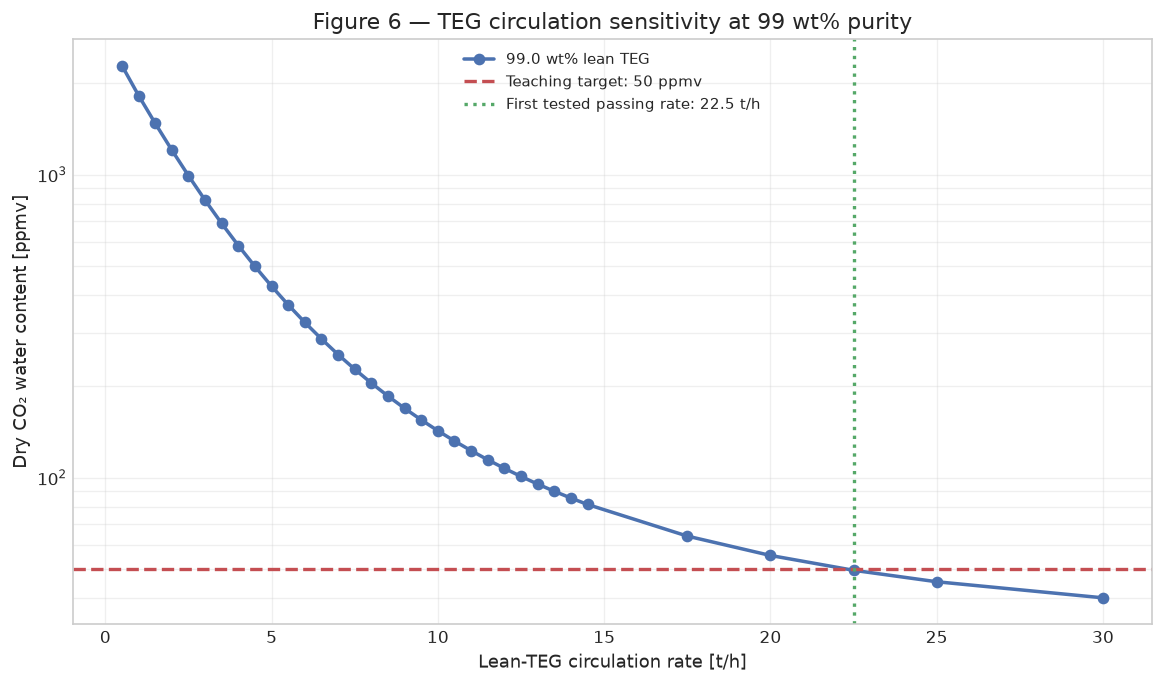

In [16]:
fig, axis = plt.subplots(figsize=(9.8, 5.8))
axis.plot(
    teg_sensitivity["TEG rate [kg/h]"] / 1_000.0,
    teg_sensitivity["Dry CO₂ water [ppmv]"],
    color="#4C72B0",
    marker="o",
    linewidth=2.1,
    label=f"{100.0 * BASE_TEG_MASS_FRACTION:.1f} wt% lean TEG",
)
axis.axhline(
    WATER_TARGET_PPMV,
    color="#C44E52",
    linestyle="--",
    linewidth=2.0,
    label=f"Teaching target: {WATER_TARGET_PPMV:.0f} ppmv",
)
axis.axvline(
    selected_teg_rate / 1_000.0,
    color="#55A868",
    linestyle=":",
    linewidth=2.0,
    label=f"First tested passing rate: {selected_teg_rate / 1_000.0:.1f} t/h",
)
axis.set_xlabel("Lean-TEG circulation rate [t/h]")
axis.set_ylabel("Dry CO₂ water content [ppmv]")
axis.set_yscale("log")
axis.set_title("Figure 6 — TEG circulation sensitivity at 99 wt% purity")
axis.legend()
axis.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

The curve shows diminishing returns: solvent circulation alone cannot compensate efficiently for
finite lean-TEG water content. The selected point is the smallest **tested** passing rate, not a
continuous optimum and not a detailed column design.

## 6. Lean-TEG purity and stage sensitivity

Lean-solvent purity and theoretical contact are coupled design variables. The following cases
hold circulation at 15 t/h and vary purity and stage count. This demonstrates how users can reuse
the same model builder for independent engineering scenarios.

In [17]:
purity_values = np.array([0.990, 0.995, 0.999])
stage_values = np.array([4, 5, 6, 7])
purity_stage_rows = []

for teg_mass_fraction in purity_values:
    for number_of_stages in stage_values:
        case = build_teg_process(
            15_000.0,
            teg_mass_fraction,
            number_of_stages=int(number_of_stages),
        )
        results = summarize_teg_case(case)
        purity_stage_rows.append(
            {
                "Lean TEG [wt%]": 100.0 * teg_mass_fraction,
                "Stages [-]": number_of_stages,
                "Dry CO₂ water [ppmv]": results["Dry CO₂ water [ppmv]"],
                "Mass residual [kg/h]": results["Mass residual [kg/h]"],
            }
        )

purity_stage_table = pd.DataFrame(purity_stage_rows)
display(purity_stage_table)

,Lean TEG [wt%],Stages [-],Dry CO₂ water [ppmv],Mass residual [kg/h]
0,99.0,4,135.349355,-6.548362e-08
1,99.0,5,77.851150,-6.542541e-08
2,99.0,6,52.479346,-6.548362e-08
3,99.0,7,41.245647,-6.548362e-08
4,99.5,4,119.815791,-6.135087e-08
5,99.5,5,61.980436,-6.158371e-08
6,99.5,6,36.451824,-6.146729e-08
7,99.5,7,25.145079,-6.152550e-08
8,99.9,4,107.416066,-5.861511e-08
9,99.9,5,49.311354,-5.849870e-08


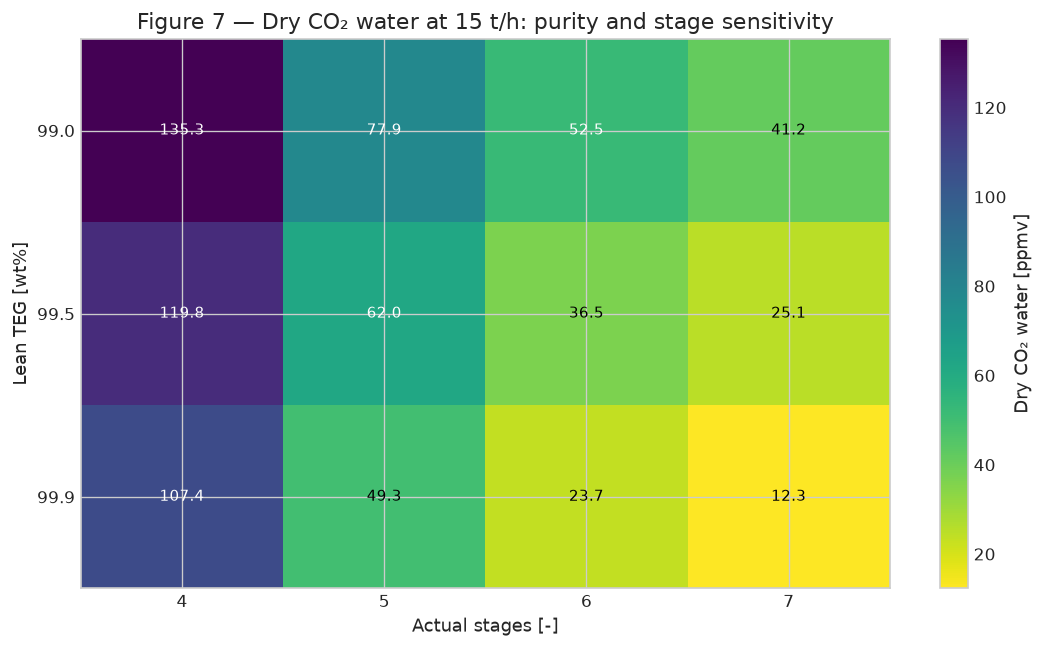

In [18]:
pivot_table = purity_stage_table.pivot(
    index="Lean TEG [wt%]",
    columns="Stages [-]",
    values="Dry CO₂ water [ppmv]",
)

fig, axis = plt.subplots(figsize=(9.3, 5.5))
image = axis.imshow(
    pivot_table.values,
    cmap="viridis_r",
    aspect="auto",
)
axis.set_xticks(np.arange(len(pivot_table.columns)))
axis.set_xticklabels([f"{int(value)}" for value in pivot_table.columns])
axis.set_yticks(np.arange(len(pivot_table.index)))
axis.set_yticklabels([f"{value:.1f}" for value in pivot_table.index])
axis.set_xlabel("Actual stages [-]")
axis.set_ylabel("Lean TEG [wt%]")
axis.set_title(
    "Figure 7 — Dry CO₂ water at 15 t/h: purity and stage sensitivity"
)

for row_index in range(pivot_table.shape[0]):
    for column_index in range(pivot_table.shape[1]):
        value = pivot_table.values[row_index, column_index]
        text_color = "white" if value > np.nanmedian(pivot_table.values) else "black"
        axis.text(
            column_index,
            row_index,
            f"{value:.1f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=9,
        )

colorbar = fig.colorbar(image, ax=axis)
colorbar.set_label("Dry CO₂ water [ppmv]")
plt.tight_layout()
plt.show()

Increasing purity and stage count both reduce product water. The heat map is valuable for
screening, but stage efficiency, solvent degradation, CO₂ solubility, entrainment, packing
hydraulics, and regeneration energy require a more complete model and project data.

## 7. Final application: a reusable passing screening case

The final workflow reuses the model builder at the selected rate, retrieves product streams,
checks water quality and absorber loading, and closes total and component balances:

$$

\Delta \dot m_i =
\sum \dot m_{i,\mathrm{in}} -
\sum \dot m_{i,\mathrm{out}}

$$

A small residual relative to throughput demonstrates conservation in the executed process model.

In [19]:
design_case = build_teg_process(
    selected_teg_rate,
    BASE_TEG_MASS_FRACTION,
)
design_results = summarize_teg_case(design_case)

design_summary = pd.DataFrame(
    [
        ("Wet CO₂ water", design_results["Wet CO₂ water [ppmv]"], "ppmv"),
        ("Dry CO₂ water", design_results["Dry CO₂ water [ppmv]"], "ppmv"),
        ("Water removal", 100.0 * design_results["Water removal [-]"], "%"),
        ("Dry CO₂ product", design_results["Dry CO₂ [kg/h]"], "kg/h"),
        ("Rich TEG product", design_results["Rich TEG [kg/h]"], "kg/h"),
        ("Fs factor", design_results["Fs factor [Pa^0.5]"], "Pa^0.5"),
        ("Fs utilization", design_results["Fs utilization [%]"], "%"),
        ("Minimum diameter", design_results["Minimum diameter [m]"], "m"),
    ],
    columns=["Quantity", "Value", "Unit"],
)
display(design_summary)

,Quantity,Value,Unit
0,Wet CO₂ water,3309.780339,ppmv
1,Dry CO₂ water,49.428514,ppmv
2,Water removal,98.522557,%
3,Dry CO₂ product,496280.920802,kg/h
4,Rich TEG product,26219.079198,kg/h
5,Fs factor,0.759407,Pa^0.5
6,Fs utilization,25.313576,%
7,Minimum diameter,1.509378,m


In [20]:
components = ["CO2", "nitrogen", "water", "TEG"]
component_balance_rows = []

for component_name in components:
    inlet_rate = component_mass_rate(
        design_case["feed"],
        component_name,
    ) + component_mass_rate(
        design_case["lean_teg"],
        component_name,
    )
    outlet_rate = component_mass_rate(
        design_case["dry_co2"],
        component_name,
    ) + component_mass_rate(
        design_case["rich_teg"],
        component_name,
    )
    component_balance_rows.append(
        {
            "Component": component_name,
            "Inlet [kg/h]": inlet_rate,
            "Outlet [kg/h]": outlet_rate,
            "Residual [kg/h]": inlet_rate - outlet_rate,
        }
    )

component_balance_table = pd.DataFrame(component_balance_rows)
display(component_balance_table)

maximum_component_residual = float(
    component_balance_table["Residual [kg/h]"].abs().max()
)
relative_mass_residual = abs(
    design_results["Mass residual [kg/h]"]
) / (
    CO2_FEED_KG_PER_HOUR + selected_teg_rate
)

print(f"Maximum component residual: {maximum_component_residual:.3e} kg/h")
print(f"Relative total-mass residual: {relative_mass_residual:.3e}")

Maximum component residual: 3.194e-09 kg/h
Relative total-mass residual: 4.122e-15


,Component,Inlet [kg/h],Outlet [kg/h],Residual [kg/h]
0,CO2,496109.749082,496109.749082,1.222361e-09
1,nitrogen,3209.025781,3209.025781,1.045919e-11
2,water,708.455787,708.455787,-9.242740e-11
3,TEG,22472.769349,22472.769349,-3.194145e-09


## Validation checks

The evidence level is thermodynamic consistency, conservation, nearby scenarios, and a
pure-fluid reference-model comparison. The notebook does not claim certification against a
specific CCS project or standard.

In [21]:
validation_checks = {
    "Runtime uses public NeqSim 3.16.0": NEQSIM_VERSION == "3.16.0",
    "Saturated base has CO₂-rich and aqueous phases": (
        saturated_base.getNumberOfPhases() >= 2
    ),
    "Water-map values are finite": np.isfinite(
        water_map["Water [ppmv]"]
    ).all(),
    "Warmer cases carry more water at 20 bara": (
        water_map.loc[
            water_map["Pressure [bara]"] == 20.0,
            "Water [ppmv]",
        ].iloc[-1]
        >
        water_map.loc[
            water_map["Pressure [bara]"] == 20.0,
            "Water [ppmv]",
        ].iloc[0]
    ),
    "Envelope has finite dew and bubble points": (
        dew_mask.sum() > 10 and bubble_mask.sum() > 10
    ),
    "All density values are finite and positive": (
        np.isfinite(density_table["SRK mixture density [kg/m³]"]).all()
        and (density_table["SRK mixture density [kg/m³]"] > 0.0).all()
    ),
    "Base case preserves the original failing 5 t/h case": (
        base_results["Dry CO₂ water [ppmv]"] > WATER_TARGET_PPMV
    ),
    "Rate sensitivity is finite": np.isfinite(
        teg_sensitivity["Dry CO₂ water [ppmv]"]
    ).all(),
    "More TEG monotonically lowers dry-product water": (
        np.diff(teg_sensitivity["Dry CO₂ water [ppmv]"]) < 0.0
    ).all(),
    "A tested circulation rate meets the target": (
        design_results["Dry CO₂ water [ppmv]"] <= WATER_TARGET_PPMV
    ),
    "Design case removes more than 95% of feed water": (
        design_results["Water removal [-]"] > 0.95
    ),
    "Design total-mass residual is below 1e-9 relative": (
        relative_mass_residual < 1.0e-9
    ),
    "Design component residual is below 1e-5 kg/h": (
        maximum_component_residual < 1.0e-5
    ),
    "Every sensitivity mass residual is below 1e-4 kg/h": (
        teg_sensitivity["Mass residual [kg/h]"].abs() < 1.0e-4
    ).all(),
    "Every purity-stage mass residual is below 1e-4 kg/h": (
        purity_stage_table["Mass residual [kg/h]"].abs() < 1.0e-4
    ).all(),
    "Fs factor is within the configured design limit": (
        design_case["absorber"].isFsFactorWithinDesignLimit()
    ),
    "Screening diameter exceeds NeqSim minimum": (
        CONTACTOR_DIAMETER_M >= design_results["Minimum diameter [m]"]
    ),
}

validation_table = pd.DataFrame(
    [
        {"Check": name, "Passed": bool(passed)}
        for name, passed in validation_checks.items()
    ]
)
display(validation_table)

assert validation_table["Passed"].all()
print(f"All {len(validation_checks)} engineering checks passed.")

All 17 engineering checks passed.


,Check,Passed
0,Runtime uses public NeqSim 3.16.0,True
1,Saturated base has CO₂-rich and aqueous phases,True
2,Water-map values are finite,True
3,Warmer cases carry more water at 20 bara,True
4,Envelope has finite dew and bubble points,True
5,All density values are finite and positive,True
6,Base case preserves the original failing 5 t/h case,True
7,Rate sensitivity is finite,True
8,More TEG monotonically lowers dry-product water,True
9,A tested circulation rate meets the target,True


## Troubleshooting and practical limitations

- **Missing aqueous phase:** add excess water, enable multiphase checking, and run the TP flash
  before extracting the CO₂-rich phase.
- **Invalid CPA mixing-rule name:** NeqSim 3.16.0 uses mixing-rule code `10` for this
  SRK-CPA workflow; the draft string `classic_CPA` is not accepted.
- **Missing component after stream mixing:** use aligned component sets. The negligible template
  traces in `build_teg_process` prevent component-list mismatch without changing engineering mass.
- **Phase-envelope NaNs:** continuation calculations may include non-finite endpoints. Filter
  endpoints, but never suppress a failed calculation.
- **Unrealistic dry-gas result:** verify lean-TEG purity, actual/theoretical stages, flow basis,
  water-saturated feed construction, and that ppmv is mole based.
- **Design limitation:** `SimpleTEGAbsorber` is an equilibrium-stage screening model. It does not
  replace rate-based packing design, TEG regeneration, solvent degradation, corrosion,
  impurity-reaction, hydrate, or transient pipeline studies.

## Conclusions

- SRK-CPA predicts a water-saturated CO₂-rich feed far above 50 ppmv over the studied window.
- The original 5 t/h, 99 wt% TEG case is preserved and shown to miss the teaching target.
- The first tested passing circulation rate is selected from independent fresh-object cases.
- The final `ProcessSystem` retrieves dry CO₂ and rich TEG, closes total and component balances,
  and checks the native Fs-factor limit.
- Model choice, binary parameters, water specification, materials, and regeneration design must
  be qualified for each capture source and transport system.

## Further exercises

1. Replace the illustrative assay with a documented capture-source composition.
2. Add rich-TEG letdown, flash separation, regeneration, pump, and recycle.
3. Compare SRK-CPA with another validated CO₂-water model over experimental data.
4. Couple the dry product to a compressor and `PipeBeggsAndBrills` transport segment.
5. Use `RateBasedPackedColumn` when packing profiles and local transfer direction matter.

## Authoritative references

- [NeqSim thermodynamic models](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)
- [NeqSim flash calculations](https://equinor.github.io/neqsim/thermo/flash_calculations_guide.html)
- [NeqSim absorbers and TEG contactor](https://equinor.github.io/neqsim/process/equipment/absorbers.html)
- [NeqSim TEG dehydration tutorial](https://equinor.github.io/neqsim/tutorials/teg_dehydration_tutorial.html)
- [NeqSim 3.16.0 on PyPI](https://pypi.org/project/neqsim/)

Always consult the current project design basis and the applicable editions of transport,
materials, corrosion, and safety standards before engineering decisions.